In [ ]:
# Установка зависимостей
#%pip freeze -> requirements.txt

In [1]:
!pip install timm

In [2]:
import sys
sys.path.insert(0, './src')

# Import libs

In [4]:
import os
from pathlib import Path

import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm import tqdm


#from utils import dataset_processed

from OGYEI_dataset import OGYEIDataset, get_transforms
from model import create_model_and_train

BASE_DIR = Path().resolve()

BATCH_SIZE = 128
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. Get datasets: train, val, test

In [8]:
import kagglehub
data_dir = kagglehub.dataset_download("richardradli/ogyeiv2")

Using Colab cache for faster access to the 'ogyeiv2' dataset.


In [11]:
data_dir = os.path.join(data_dir,'ogyeiv2', 'ogyeiv2')

In [12]:
#data_dir = 'data'

train_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='train',
    number_split=1,  # Берем первую часть имени файла как метку
    transform=get_transforms(augment=True)  # Трансформации с аугментацией
)

val_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='valid',
    number_split=1,
    transform=get_transforms(augment=False)  # Трансформации без аугментации
)

test_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='test',
    number_split=1,
    transform=get_transforms(augment=False)  # Трансформации без аугментации
)

# Выводим информацию о датасете
print(f"Количество изображений в тренировочном наборе: {len(train_dataset)}")
print(f"Количество классов: {len(train_dataset.classes)}")
print(f"Классы: {train_dataset.classes}")

# Выводим информацию о датасете
print(f"Количество изображений в validation наборе: {len(val_dataset)}")
print(f"Количество классов: {len(val_dataset.classes)}")
print(f"Классы: {val_dataset.classes}")

# Выводим информацию о датасете
print(f"Количество изображений в тренировочном наборе: {len(test_dataset)}")
print(f"Количество классов: {len(test_dataset.classes)}")
print(f"Классы: {test_dataset.classes}")

Количество изображений в тренировочном наборе: 3136
Количество классов: 100
Классы: ['acc', 'advil', 'akineton', 'algoflex', 'algopyrin', 'ambroxol', 'apranax', 'aspirin', 'atoris', 'atorvastatin', 'betaloc', 'bila', 'c', 'calci', 'cataflam', 'cetirizin', 'co', 'cold', 'coldrex', 'concor', 'condrosulf', 'controloc', 'covercard', 'coverex', 'diclopram', 'donalgin', 'dorithricin', 'doxazosin', 'dulodet', 'dulsevia', 'enterol', 'escitil', 'favipiravir', 'frontin', 'furon', 'ibumax', 'indastad', 'jutavit', 'kalcium', 'kalium', 'ketodex', 'koleszterin', 'l', 'lactamed', 'lactiv', 'laresin', 'letrox', 'lordestin', 'magne', 'mebucain', 'merckformin', 'meridian', 'metothyrin', 'mezym', 'milgamma', 'milurit', 'naprosyn', 'narva', 'naturland', 'nebivolol', 'neo', 'no', 'noclaud', 'nolpaza', 'nootropil', 'normodipine', 'novo', 'nurofen', 'ocutein', 'olicard', 'panangin', 'pantoprazol', 'provera', 'quamatel', 'reasec', 'revicet', 'rhinathiol', 'rubophen', 'salazopyrin', 'sedatif', 'semicillin', 's

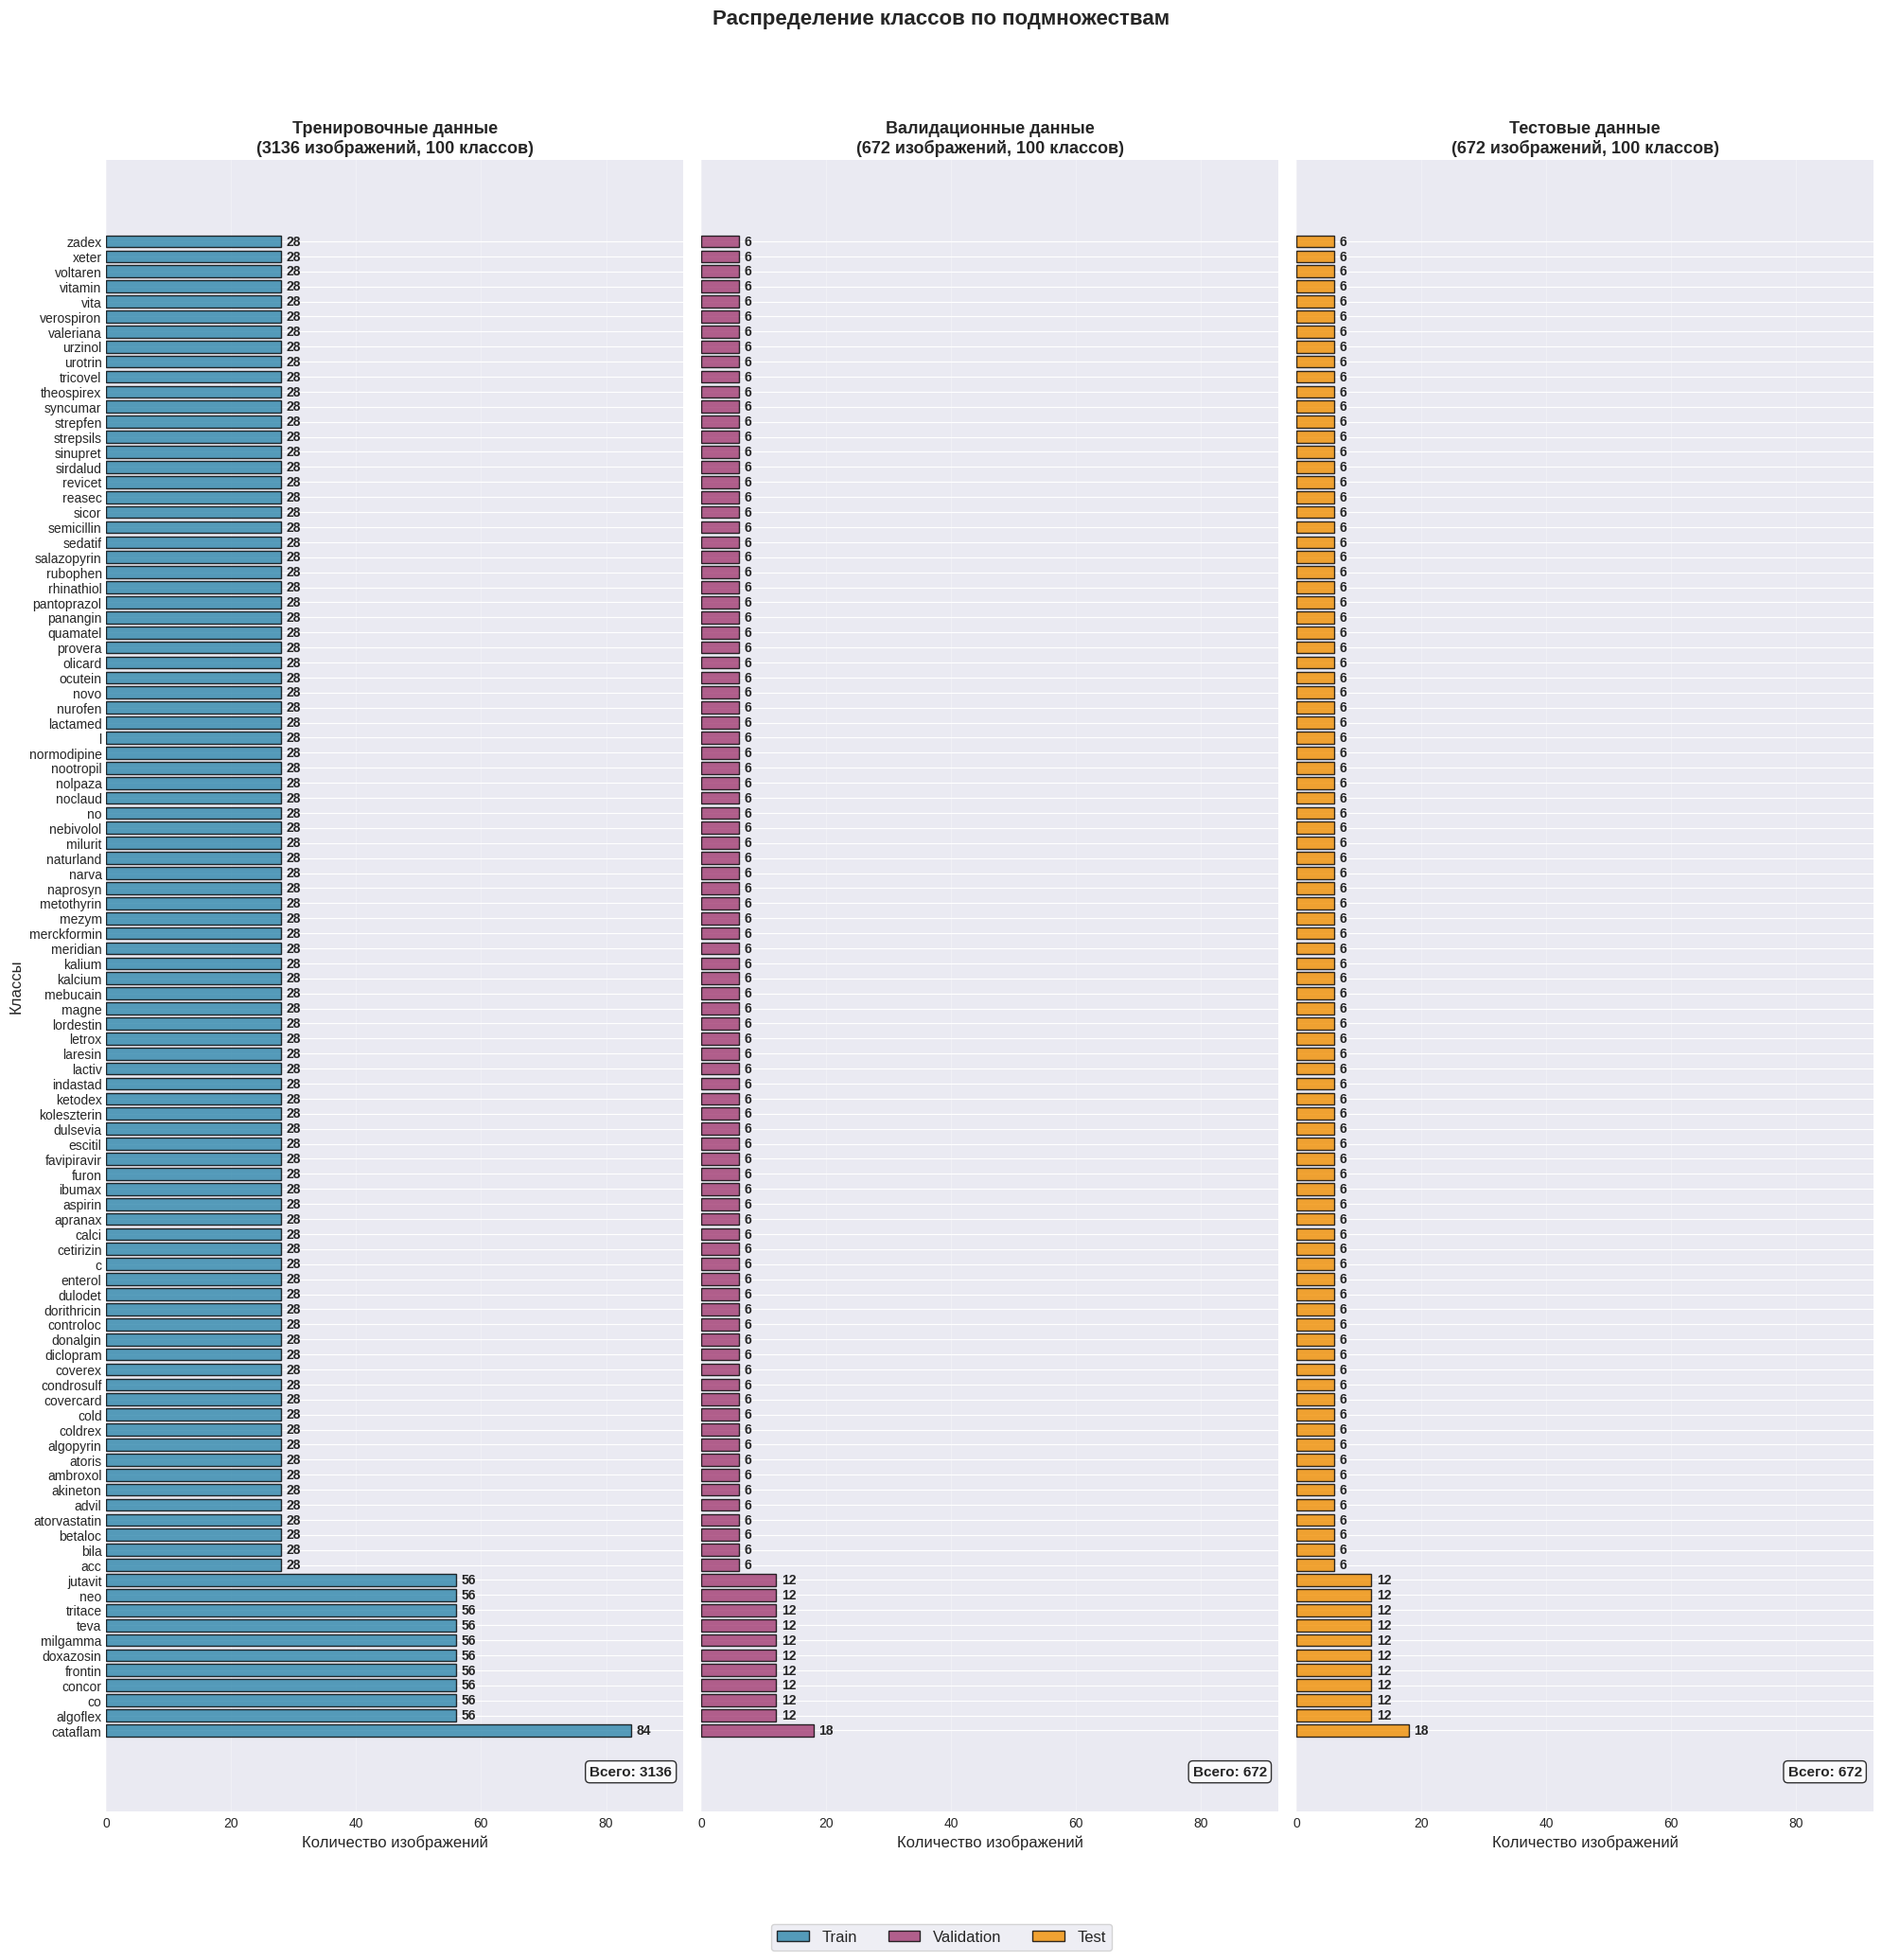

СТАТИСТИКА РАСПРЕДЕЛЕНИЯ КЛАССОВ
Всего уникальных классов: 100
Тренировочные данные: 3136 изображений, 100 классов
Валидационные данные: 672 изображений, 100 классов
Тестовые данные: 672 изображений, 100 классов
Общее количество изображений: 4480

Анализ покрытия классов:
  В Train представлены все классы
  В Validation представлены все классы
  В Test представлены все классы


,class,train,val,test,total
14,cataflam,84,18,18,120
3,algoflex,56,12,12,80
16,co,56,12,12,80
19,concor,56,12,12,80
33,frontin,56,12,12,80
...,...,...,...,...,...
95,vita,28,6,6,40
96,vitamin,28,6,6,40
97,voltaren,28,6,6,40
98,xeter,28,6,6,40


In [13]:
def plot_dataset_distributions(train_dataset, val_dataset, test_dataset, figsize=(20, 20)):
    """
    Строит гистограммы распределения классов для всех трех датасетов на одном графике

    Args:
        train_dataset: Объект тренировочного датасета
        val_dataset: Объект валидационного датасета
        test_dataset: Объект тестового датасета
        figsize: Размер фигуры
    """

    import matplotlib.pyplot as plt
    import numpy as np

    # Получаем распределение классов для каждого датасета
    train_dist = train_dataset.get_class_distribution()
    val_dist = val_dataset.get_class_distribution()
    test_dist = test_dataset.get_class_distribution()

    # Собираем все уникальные классы
    all_classes = set(train_dist.keys()) | set(val_dist.keys()) | set(test_dist.keys())
    all_classes_sorted = sorted(list(all_classes))

    # Создаем DataFrame для удобства
    data = {
        'class': all_classes_sorted,
        'train': [train_dist.get(cls, 0) for cls in all_classes_sorted],
        'val': [val_dist.get(cls, 0) for cls in all_classes_sorted],
        'test': [test_dist.get(cls, 0) for cls in all_classes_sorted],
        'total': [train_dist.get(cls, 0) + val_dist.get(cls, 0) + test_dist.get(cls, 0)
                  for cls in all_classes_sorted]
    }

    df = pd.DataFrame(data)
    df = df.sort_values('total', ascending=False)

    # Настройка стиля
    plt.style.use('seaborn-v0_8-darkgrid')

    # Создаем фигуру с тремя subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    fig.suptitle('Распределение классов по подмножествам', fontsize=16, fontweight='bold')

    # Цвета для разных датасетов
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    # Подготовка данных для графиков
    subsets = ['train', 'val', 'test']
    titles = ['Тренировочные данные', 'Валидационные данные', 'Тестовые данные']
    datasets = [train_dataset, val_dataset, test_dataset]

    # Максимальное значение для установки лимита оси Y
    max_count = max(df['train'].max(), df['val'].max(), df['test'].max())

    for idx, (ax, subset, title, dataset) in enumerate(zip(axes, subsets, titles, datasets)):
        # Получаем данные для текущего подмножества
        subset_data = df[['class', subset]].copy()
        subset_data = subset_data[subset_data[subset] > 0]  # Только классы с ненулевым количеством
        subset_data = subset_data.sort_values(subset, ascending=False)

        # Создаем гистограмму
        bars = ax.barh(subset_data['class'], subset_data[subset],
                      color=colors[idx], alpha=0.8, edgecolor='black')

        # Настройки графика
        ax.set_xlabel('Количество изображений', fontsize=12)
        ax.set_title(f'{title}\n({len(dataset)} изображений, {len(subset_data)} классов)',
                    fontsize=13, fontweight='bold')

        # Добавляем значения на столбцы
        for bar in bars:
            width = bar.get_width()
            ax.text(width + max_count * 0.01, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

        # Настройка сетки
        ax.grid(True, alpha=0.3, axis='x')
        ax.set_xlim(0, max_count * 1.1)  # Добавляем 10% запаса

        # Добавляем метку общего количества
        ax.text(0.98, 0.02, f'Всего: {df[subset].sum()}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Общие настройки
    axes[0].set_ylabel('Классы', fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Место для заголовка

    # Добавляем легенду под графиками
    fig.legend(['Train', 'Validation', 'Test'],
               loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.05),
               fontsize=12, frameon=True)

    plt.show()

    # Выводим статистику
    print("="*80)
    print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ КЛАССОВ")
    print("="*80)
    print(f"Всего уникальных классов: {len(all_classes_sorted)}")
    print(f"Тренировочные данные: {len(train_dataset)} изображений, {len(train_dist)} классов")
    print(f"Валидационные данные: {len(val_dataset)} изображений, {len(val_dist)} классов")
    print(f"Тестовые данные: {len(test_dataset)} изображений, {len(test_dist)} классов")
    print(f"Общее количество изображений: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

    # Проверяем, есть ли классы, которые отсутствуют в каком-то подмножестве

    print("\nАнализ покрытия классов:")
    for subset_name, subset_dist in [('Train', train_dist), ('Validation', val_dist), ('Test', test_dist)]:
        missing_classes = set(all_classes_sorted) - set(subset_dist.keys())
        if missing_classes:
            print(f"  В {subset_name} отсутствуют классы: {sorted(missing_classes)}")
        else:
            print(f"  В {subset_name} представлены все классы")

    return df

plot_dataset_distributions(train_dataset, val_dataset, test_dataset)

# 3. Create models and train it

In [14]:
# Создаем DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model, history = create_model_and_train(
    checkpoint_path = 'meds_classifier.pt',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=len(train_dataset.classes),  # Автоматически определяем количество классов
    model_name="efficientnet_b3",
    pretrained=True,
    freeze_backbone=True,  # Начинаем с замороженного backbone
    num_epochs=30,
    learning_rate=1e-3,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# Пример предсказания на одном изображении
print("\n" + "="*60)
print("Пример предсказания...")

# Берем один батч
images, labels = next(iter(test_loader))
single_image = images[0:1]  # Берем одно изображение

# Получаем предсказание
model.eval()
with torch.no_grad():
    logits = model(single_image.to(next(model.parameters()).device))
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

print(f"Предсказанный класс: {predicted_class}")
print(f"Вероятность: {probs[0, predicted_class]:.4f}")
print(f"Топ-3 класса: {torch.topk(probs[0], 3).indices.tolist()}")
print(f"Топ-3 вероятности: {torch.topk(probs[0], 3).values.tolist()}")


Используемое устройство: cuda
GPU: Tesla T4
Память GPU: 15.83 GB

Создание модели...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Модель создана: efficientnet_b3
Количество классов: 100
Размерность features: 1536
Backbone заморожен: True
Всего параметров: 11,534,476
Обучаемых параметров: 838,244 (7.3%)

Начало обучения...
Начинаем обучение на cuda...
Размер тренировочного набора: 3136
Размер валидационного набора: 672


Epoch 1/30 [Val]: 100%|██████████| 21/21 [00:54<00:00,  2.61s/it, loss=4.02, acc=15.6]


RuntimeError: Parent directory models does not exist.

# 4. Inference analysis

# 5. Conclusions

Based on the metric ROUGE 1 and ROUGE 2, we can draw the following conclusion: the lightweight model LSTM is not bad for the task of autocompletion of text in tweets and can be recommended for use in mobile devices.